In [1]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd, seaborn as sns, scipy.stats as stats
import os, glob

from data.movie import Frames, Audio, People # Measures
from data.spikes import Rates # LFP, BOLD
from data.behavior import Gaze, Suspense # Suspense, Valence, Arousal

from tqdm import tqdm

### helpers

In [ ]:
rescale_t = 1

min_max = lambda x: (x - x.min()) / (x.max() - x.min())

def get_clean_df(df):

    clean_df = df.copy()
    
    clean_df = clean_df.iloc[:, np.isfinite(clean_df.values).all(axis=0)] # remove nan/inf cols
    clean_df = clean_df.iloc[:, (clean_df.mean(axis=0) > 0.1).values] # remove low-FR cols
    
    print(f'dropping {df.shape[1] - clean_df.shape[1]} neurs.\nRetaining {clean_df.shape[1]} neurs.')
    return clean_df


# loading/formatting data

### 1. X: neur_N_by_T

/home/nuttidalab/Documents/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: divide by zero encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd
/home/nuttidalab/Documents/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: invalid value encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd


dropping 732 neurs.
Retaining 725 neurs.
(725, 479)


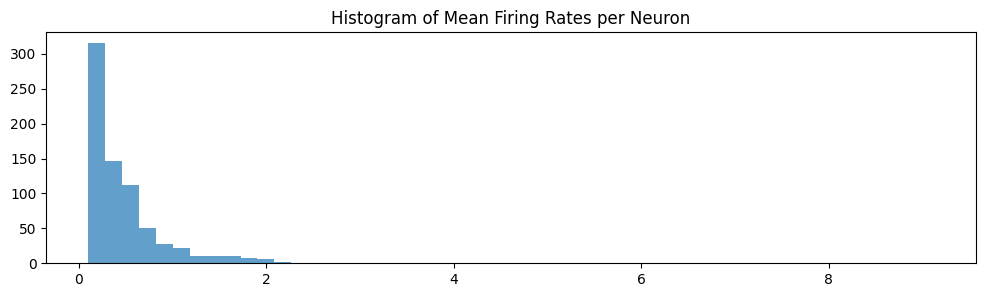

,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,Right_ACC_P58CS_R1_40_1_1392_5,Left_ACC_P58CS_R1_7_2_2044_6,Left_ACC_P58CS_R1_3_1_1880_6,Left_ACC_P58CS_R1_4_1_1616_6,...,Right_amygdala_P62CS_R1_30_2_6222_3,Right_amygdala_P62CS_R1_30_3_6240_3,Right_amygdala_P62CS_R1_31_1_2053_3,Right_amygdala_P62CS_R1_32_5_6098_3,Right_amygdala_P62CS_R1_32_7_6127_3,Right_amygdala_P62CS_R1_25_3_3529_3,Right_amygdala_P62CS_R1_27_7_8732_3,Right_preSMA_P62CS_R1_18_2_3846_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0.0,-0.107521,-0.923221,-0.088289,2.244494,0.302122,0.393852,2.372100,0.936156,0.140956,0.830868,...,0.493661,0.761268,-0.266889,0.479499,0.892620,0.801637,1.105981,1.280264,-0.457766,-0.062201
1.0,-0.107521,-1.000089,0.340222,2.887818,1.296439,1.549817,1.039705,1.616515,0.000657,0.185396,...,1.502400,0.003686,-0.266889,1.085665,1.706616,-0.198789,1.131763,0.209403,-0.005204,-0.294342
2.0,-0.107521,-0.134325,0.593294,6.613831,1.113987,0.294318,1.219149,0.045229,-0.383574,0.751941,...,0.420106,-0.558530,-0.209911,0.913765,0.839210,0.011677,0.601093,0.858131,-0.225080,-0.296496
3.0,-0.107521,2.040038,0.389511,2.013020,1.050507,1.038302,-0.164647,-0.261634,-0.374156,0.575025,...,0.593046,0.356670,0.416918,0.778260,1.195550,0.596177,0.679405,0.476378,0.028679,-0.220789
4.0,-0.107521,0.512235,-0.457154,0.090433,0.260862,0.102534,-0.171231,0.015822,-0.147529,1.453088,...,0.624067,1.322320,0.029847,0.659739,0.908040,-0.058588,0.833012,0.302962,0.120814,0.327731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474.0,-0.107521,0.031678,0.119806,-0.107521,-0.257123,-0.462101,-0.171298,0.222903,0.181188,1.323330,...,1.103151,-0.111232,0.753927,0.339228,0.546652,-0.285890,-0.065369,0.812446,0.228790,0.044538
475.0,0.076115,-0.292360,0.286691,-0.107521,0.219609,0.014690,-0.171499,-0.443767,-0.093886,1.022086,...,0.984110,-0.369311,-0.266629,0.537460,0.633420,0.748504,0.020661,-0.409717,0.229811,0.703491
476.0,2.844863,-0.093900,0.245846,-0.107521,0.709171,-0.455701,-0.171499,-0.305125,-0.559262,-0.162091,...,0.798093,0.159740,-0.266889,0.597261,0.596048,0.498692,1.324447,-0.000177,0.352840,0.230458
477.0,2.233755,0.705968,0.836228,0.030206,0.268840,-0.489116,-0.083627,0.219693,-0.617061,-0.183114,...,0.133074,0.405916,-0.266889,-0.064541,0.505282,-0.121619,1.596634,-0.224824,0.028679,0.538756


In [3]:
df_FRs = Rates().rescale(rescale_t)
clean_df_FRs = get_clean_df(df_FRs)

neur_T_by_N, neur_N_by_T = clean_df_FRs.values, clean_df_FRs.values.T
print(neur_N_by_T.shape)

plt.figure(figsize=(12, 3))
plt.hist(neur_T_by_N.mean(axis=0), bins=50, alpha=0.7)
plt.title('Histogram of Mean Firing Rates per Neuron')
plt.show()

clean_df_FRs


In [4]:
regions = ['ACC', 'amygdala', 'hippocampus', 'vmPFC', 'preSMA']

amyg_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'amyg' in col]]
amyg_T_by_N, amyg_N_by_T = amyg_df.values, amyg_df.values.T
ACC_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'ACC' in col]]
ACC_T_by_N, ACC_N_by_T = ACC_df.values, ACC_df.values.T
hippo_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'hippo' in col]]
hippo_T_by_N, hippo_N_by_T = hippo_df.values, hippo_df.values.T
vmPFC_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'vmPFC' in col]]
vmPFC_T_by_N, vmPFC_N_by_T = vmPFC_df.values, vmPFC_df.values.T
preSMA_df = clean_df_FRs[[col for col in clean_df_FRs.columns if 'preSMA' in col]]
preSMA_T_by_N, preSMA_N_by_T = preSMA_df.values, preSMA_df.values.T

### 2. Y1: sens_N_by_T and sens_N_by_T

visual

In [5]:
visual = Frames()
visual_metrics = [
    visual.objects.people_count,
    visual.cuts.scene,
    visual.cuts.camera,
    visual.measures.l1,
    visual.measures.l2,
    # visual.measures.cosine,
    # visual.measures.ssim,
    visual.measures.wasserstein,
    # visual.measures.correlation
]

100%|██████████| 144/144 [00:00<00:00, 177.49it/s]


(6, 479)


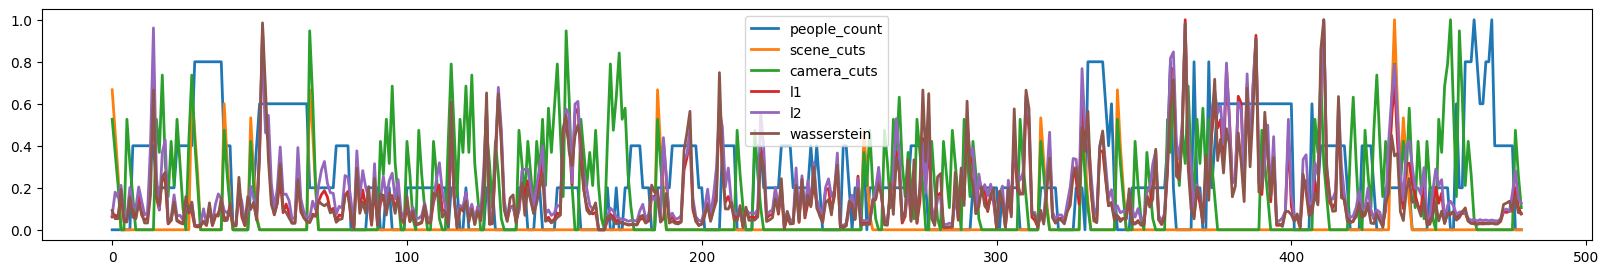

In [6]:
# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in visual_metrics]
vis_T_by_N = np.stack(rescaled_metrics, axis=1)
vis_N_by_T = vis_T_by_N.T
print(vis_N_by_T.shape)

# plot
visual_df = pd.DataFrame(vis_T_by_N, columns=[
    'people_count', 'scene_cuts', 'camera_cuts',
    'l1', 'l2', 'wasserstein'
])
plt.figure(figsize=(20, 3))
for col in visual_df.columns:
    # if not col == 'wasserstein': continue
    plt.plot(min_max(visual_df[col]), label=col, linewidth=2)
plt.legend()
plt.show()

audio

In [7]:
audio = Audio()
audio_metrics = [
    audio.vocals.arousal,
    audio.vocals.dominance,
    audio.vocals.valence,
    # audio.vocals.angry,
    audio.vocals.sad,
    audio.vocals.happy,
    # audio.vocals.surprise,
    audio.vocals.neutral,
]

(6, 479)


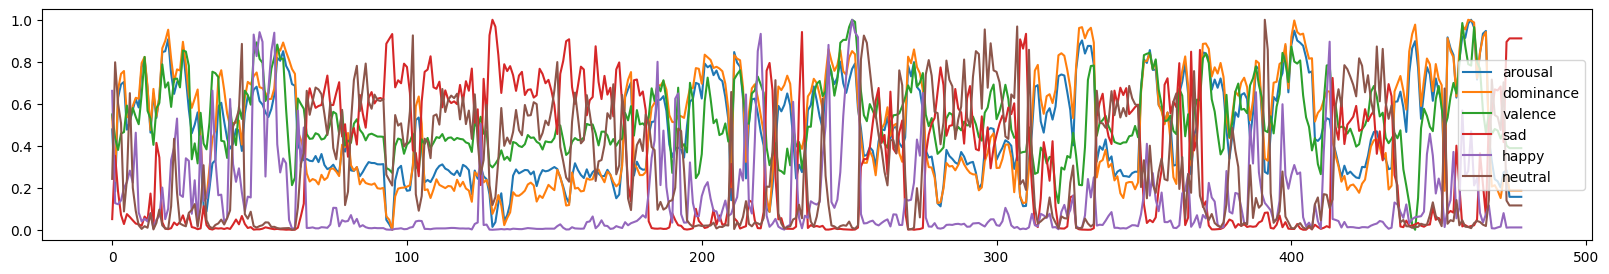

In [8]:
# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in audio_metrics]
aud_T_by_N = np.stack(rescaled_metrics, axis=1)
aud_N_by_T = aud_T_by_N.T
print(aud_N_by_T.shape)

# plot
audio_df = pd.DataFrame(aud_T_by_N, columns=['arousal', 'dominance', 'valence','sad', 'happy','neutral'])
plt.figure(figsize=(20, 3))
for col in audio_df.columns:
    plt.plot(min_max(audio_df[col]), label=col)
plt.legend()
plt.show()

combine

(1, 479)


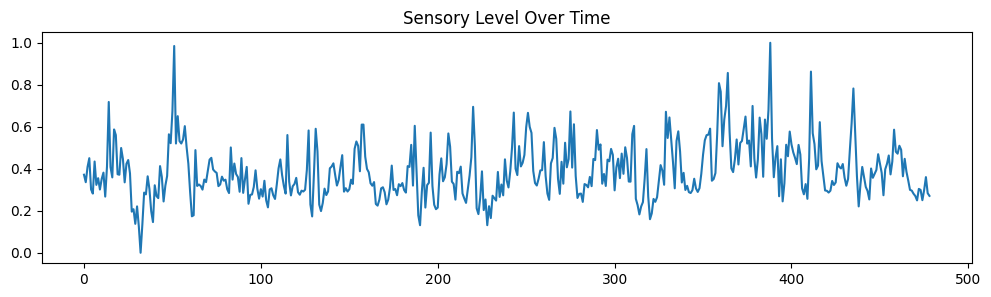

In [9]:
aud_level = min_max(aud_T_by_N.mean(axis=1))
vis_level = min_max(vis_T_by_N.mean(axis=1))
sens_N_by_T = ((aud_level + vis_level) / 2).reshape(1, -1)
# sens_N_by_T = np.concatenate([aud_T_by_N, vis_T_by_N], axis=1).T
sens_T_by_N = sens_N_by_T.T
print(sens_N_by_T.shape)
sens_df = pd.DataFrame(sens_T_by_N, columns=['sensory_level'])

plt.figure(figsize=(12, 3))
plt.plot(min_max(sens_T_by_N.mean(axis=1)))
plt.title('Sensory Level Over Time')
plt.show()  

### 3. Y2: susp_N_T

(1, 479)


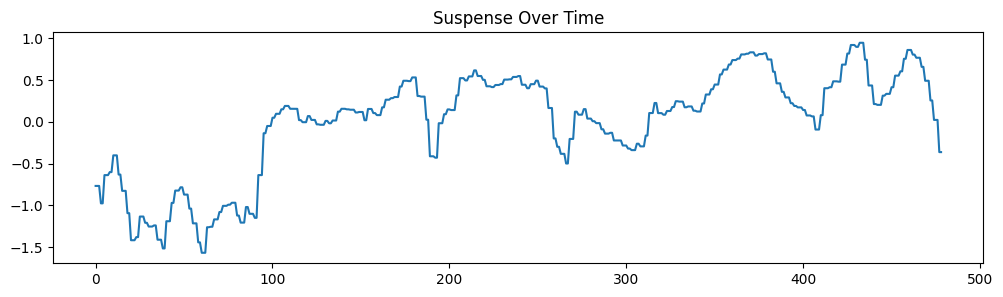

In [10]:
suspense = Suspense().rescale(rescale_t)
avg_suspense = suspense.mean(axis=1)
df_susp = pd.DataFrame(avg_suspense, columns=['suspense'])
susp_N_by_T = avg_suspense[np.newaxis, :]
print(susp_N_by_T.shape)

plt.figure(figsize=(12, 3))
plt.title('Suspense Over Time')
plt.plot(avg_suspense)
plt.show()

## get correlated neurons

In [18]:
def get_corr_neurs(neur_df, visual_df, audio_df, susp_df):
    """
    Get corr_df and pval_df of each neur col with each col of visual, audio, and suspense dataframes.
    """
    corr_df = pd.DataFrame(index=neur_df.columns, columns=visual_df.columns.tolist() + audio_df.columns.tolist() + susp_df.columns.tolist())
    pval_df = pd.DataFrame(index=neur_df.columns, columns=visual_df.columns.tolist() + audio_df.columns.tolist() + susp_df.columns.tolist())

    for neur_col in tqdm(neur_df.columns):
        
        for vis_col in visual_df.columns:
            corr, pval = stats.pearsonr(neur_df[neur_col], visual_df[vis_col])
            corr_df.loc[neur_col, vis_col] = corr
            pval_df.loc[neur_col, vis_col] = pval

        for aud_col in audio_df.columns:
            corr, pval = stats.pearsonr(neur_df[neur_col], audio_df[aud_col])
            corr_df.loc[neur_col, aud_col] = corr
            pval_df.loc[neur_col, aud_col] = pval
        
        for susp_col in susp_df.columns:
            corr, pval = stats.pearsonr(neur_df[neur_col], susp_df[susp_col])
            corr_df.loc[neur_col, susp_col] = corr
            pval_df.loc[neur_col, susp_col] = pval

    return corr_df.astype(float), pval_df.astype(float)
    
# Get correlation dataframes
neur_corrs, neur_pvals = get_corr_neurs(clean_df_FRs, visual_df, audio_df, df_susp)
neur_corrs = neur_corrs.reset_index().rename(columns={'index': 'neuron'})
neur_pvals = neur_pvals.reset_index().rename(columns={'index': 'neuron'})
neur_corrs

100%|██████████| 725/725 [00:01<00:00, 617.12it/s]


,neuron,people_count,scene_cuts,camera_cuts,l1,l2,wasserstein,arousal,dominance,valence,sad,happy,neutral,suspense
0,Right_ACC_P58CS_R1_35_1_2195_5,0.035208,-0.001736,-0.031279,-0.039420,-0.037155,-0.029795,-0.043730,-0.052286,0.014711,-0.001085,-0.004042,0.039103,-0.177434
1,Right_ACC_P58CS_R1_34_4_3301_5,-0.065109,0.068741,0.075554,-0.043613,-0.060825,-0.018030,-0.016013,0.015817,-0.028941,-0.026223,0.069263,-0.062181,-0.045350
2,Right_ACC_P58CS_R1_34_2_3239_5,0.067705,0.036262,-0.038847,-0.036236,-0.030333,-0.027356,0.016357,0.043810,-0.133713,-0.074310,-0.028620,-0.057001,-0.100961
3,Right_ACC_P58CS_R1_36_1_712_5,0.128921,-0.004331,0.072624,0.096781,0.104373,0.077217,0.050261,0.067986,0.079819,-0.059906,0.064455,-0.041895,-0.053208
4,Right_ACC_P58CS_R1_36_2_962_5,0.129334,-0.048383,0.008497,0.120616,0.131216,0.089265,-0.044133,-0.040918,0.046495,0.003581,0.057030,0.006137,0.007404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,Right_amygdala_P62CS_R1_25_3_3529_3,-0.013609,-0.072619,-0.011347,-0.003235,0.000796,-0.003620,-0.045645,-0.055920,-0.100527,0.050500,-0.094609,-0.009815,0.031335
721,Right_amygdala_P62CS_R1_27_7_8732_3,0.002827,-0.025852,0.039302,-0.034600,-0.036058,-0.017568,-0.105691,-0.093694,-0.002801,0.045407,0.063392,-0.003147,-0.258271
722,Right_preSMA_P62CS_R1_18_2_3846_7,0.057583,-0.004486,-0.112902,0.053516,0.071725,0.056519,0.032613,0.033739,0.033818,-0.083869,0.072039,-0.014660,-0.161059
723,Right_vmPFC_P62CS_R1_7_1_791_9,0.087543,0.049468,-0.071661,0.012159,0.014729,-0.008527,-0.033014,-0.010338,-0.035429,-0.037047,0.010828,-0.018359,-0.068595


In [23]:
for metric in neur_corrs.columns:

    if metric == 'neuron': continue
    tuned_neurs = neur_corrs.index[(neur_corrs[metric] > 0.2) & (neur_pvals[metric] < 0.05)]
    print(f'Found {len(tuned_neurs)} neurons with significant correlation to {metric}.')

Found 13 neurons with significant correlation to people_count.
Found 4 neurons with significant correlation to scene_cuts.
Found 2 neurons with significant correlation to camera_cuts.
Found 3 neurons with significant correlation to l1.
Found 2 neurons with significant correlation to l2.
Found 1 neurons with significant correlation to wasserstein.
Found 9 neurons with significant correlation to arousal.
Found 11 neurons with significant correlation to dominance.
Found 0 neurons with significant correlation to valence.
Found 15 neurons with significant correlation to sad.
Found 5 neurons with significant correlation to happy.
Found 10 neurons with significant correlation to neutral.
Found 29 neurons with significant correlation to suspense.


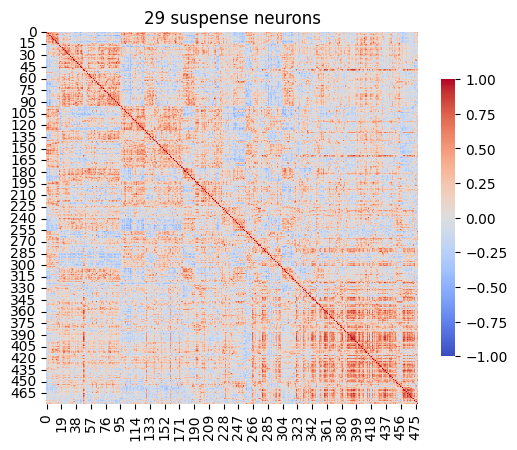

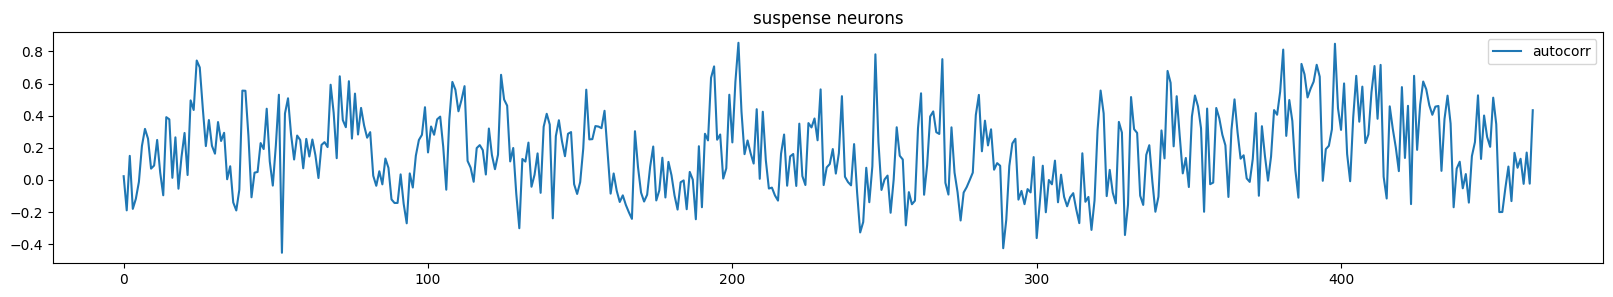

In [39]:
# plot time by time corr of susp_neurs
susp_neurs = neur_corrs[
    (neur_corrs['suspense'] > .2) & 
    (neur_pvals['suspense'] < .05)
]['neuron'].tolist()

susp_neur_df = clean_df_FRs[susp_neurs]
plt.figure(figsize=(6, 6))
sns.heatmap(np.corrcoef(susp_neur_df), cmap='coolwarm', square=True, vmin=-1, vmax=1, cbar_kws={'shrink': .6})
plt.title(f'{len(susp_neurs)} suspense neurons')
plt.show()

# also plot
plt.figure(figsize=(20, 3))
# plt.plot(susp_neur_df.mean(axis=1), label='mean FR')
plt.plot(np.diag(np.corrcoef(susp_neur_df), 15), label='autocorr')
plt.legend()
plt.title('suspense neurons')
plt.show()

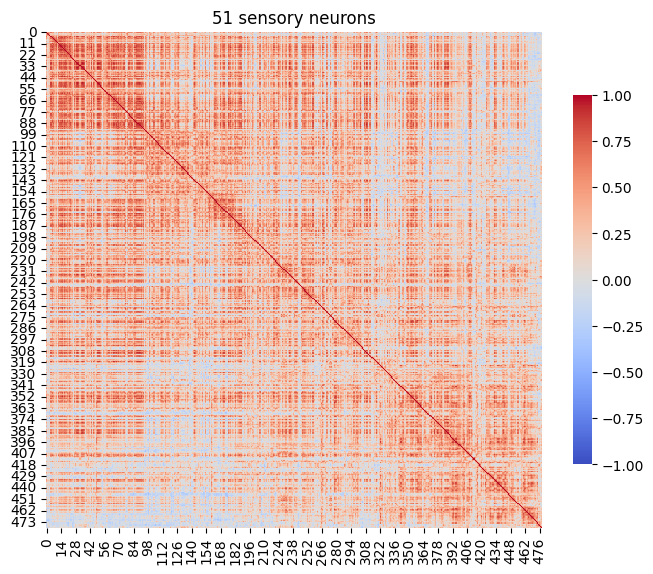

In [24]:
sens_neurs = neur_corrs[
    (neur_corrs.drop(columns=['neuron', 'suspense']) > 0.2).any(axis=1) &
    (neur_pvals.drop(columns=['neuron', 'suspense']) < 0.05).any(axis=1)
]['neuron'].tolist()

sens_neur_df = clean_df_FRs[sens_neurs]
plt.figure(figsize=(8, 8))
sns.heatmap(np.corrcoef(sens_neur_df), cmap='coolwarm', square=True, vmin=-1, vmax=1, cbar_kws={'shrink': .6})
plt.title(f'{len(sens_neurs)} sensory neurons')
plt.show()
